---
title: Linear Regression
author: Andrei Akopian
date: 2026-02-14
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

Baseline linear regression for unmixing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

In [2]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [3]:
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"
LAB_DATA = "../../../data/useful_columns_data.csv"

In [4]:
df = helper_functions.open_file(LAB_DATA)
fractions, nr900to1690_raw = helper_functions.take_subset(df,start=900,end=1690)

# Naive Linear Regression

A naive linear regression, without adjusting to the specifics of the dataset in anyway.

In [5]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690_raw, fractions.to_numpy(), test_size=0.5, random_state=42)
naive_regression = sklearn.linear_model.LinearRegression()
naive_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Naive linear regression sticks outside of the [0, 1] range.

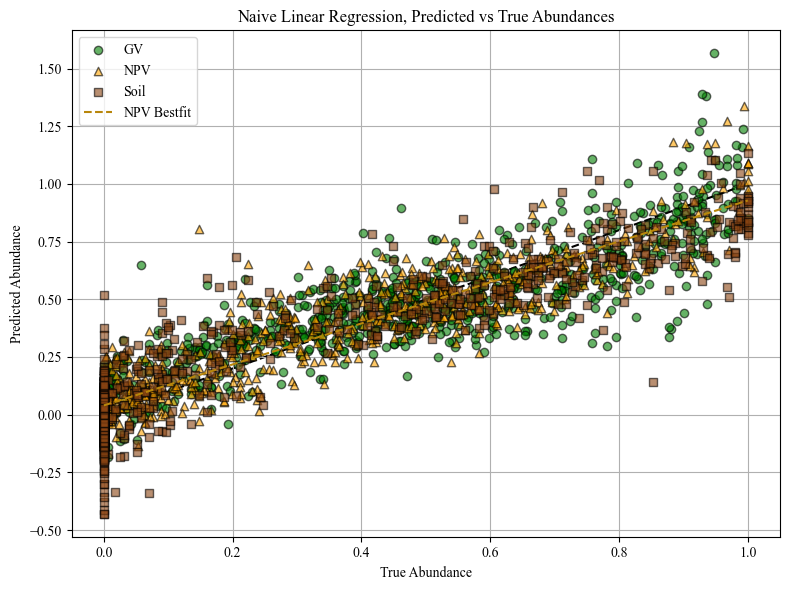

npv r^2 = 0.7475517522373676
gv r^2 = 0.8600638030136386
soil r^2 = 0.8471846952039254
mean r^2 = 0.8182667501516439
rmse = 0.1307196256416229


In [6]:
ab_true_np_array = y_test
ab_predictions = naive_regression.predict(X_test)
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_predictions,
    model_name="Naive Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

We clip the predicted abundances to [0,1] range, and visually confirm that the fractions add up roughly to 1.

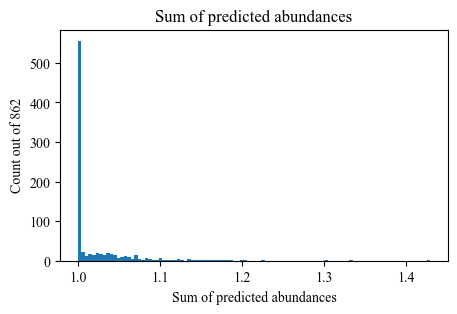

In [7]:
# | output: false
# | code-fold: true
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
helper_functions.simple_histogram(ab_clipped_predictions.sum(axis=1), title="Sum of predicted abundances", x_label="Sum of predicted abundances", y_label=f"Count out of {y_test.shape[0]}", bins=100)

Clipped prediction plot:

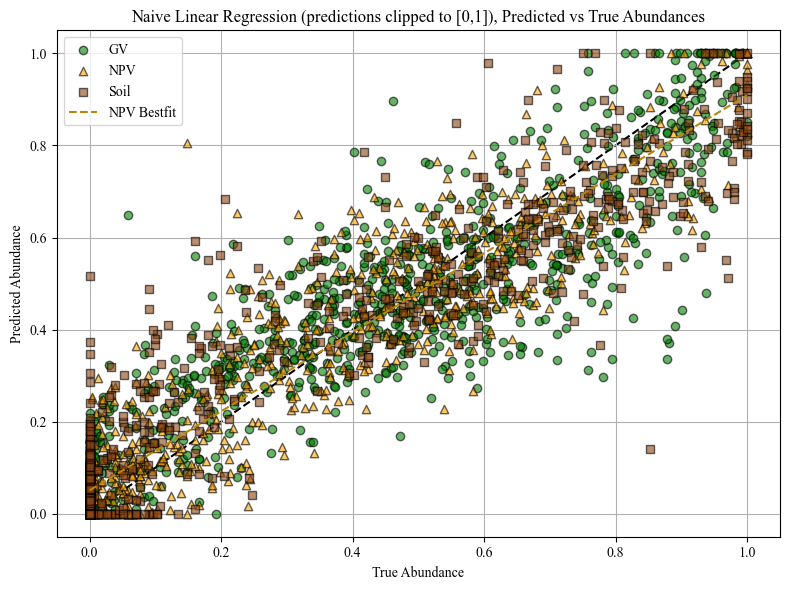

npv r^2 = 0.7680414638043341
gv r^2 = 0.8697419275912325
soil r^2 = 0.8872822361726816
mean r^2 = 0.8416885425227494
rmse = 0.1307196256416229


In [9]:
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Naive Linear Regression (predictions clipped to [0,1])",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipped_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

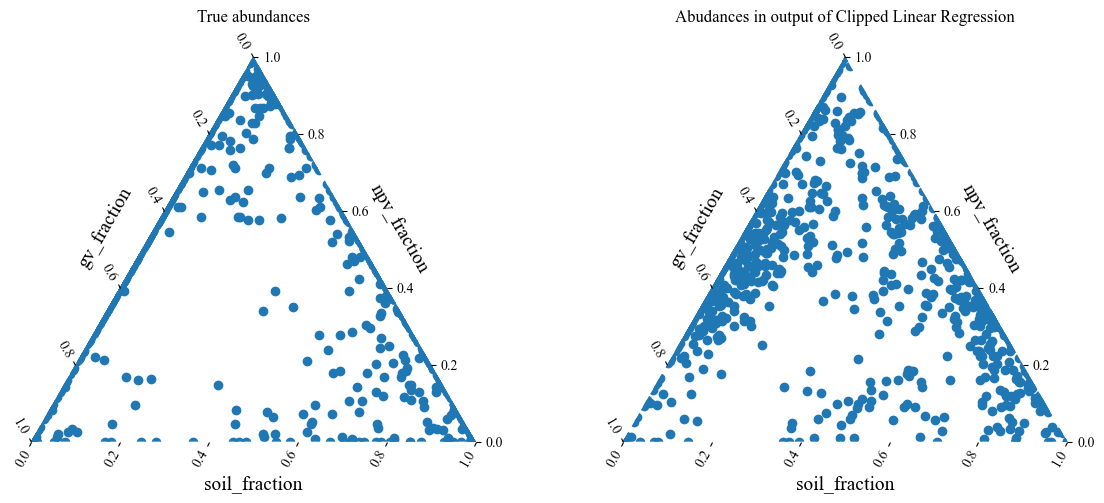

In [10]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Clipped Linear Regression")

# Better Linear Regression

The naive linear regression, has a number of drawbacks, such as forcing values to be clipped.

Also, naive linear regression ignored rows that were missing one of the 3 abundances. ([See `dataset_characterization.ipynb`](../characterization/dataset_characterization.ipynb))

This linear regression model will:
- train the abundanees separately, only using
- transform the results using a logit function into the [0, 1] range instead of clipping

In [17]:
logit = lambda x: scipy.special.logit((x-np.float64(0.5))*np.float64(0.90)+np.float64(0.5))
expit = scipy.special.expit

In [18]:
X_train_raw, X_test_raw, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions, test_size=0.5, random_state=42)

def normalize(frame):
    return sklearn.preprocessing.normalize(frame,norm='l2',axis=1)

npv_indecies = {i for i, value in enumerate(df['has_npv']) if value}
gv_indecies = {i for i, value in enumerate(df['has_gv']) if value}
soil_indecies = {i for i, value in enumerate(df['has_soil']) if value}
training_indecies = set(X_train.index)

# fit regressions
npv_train_indecies = list(training_indecies.intersection(npv_indecies))
npv_regression = sklearn.linear_model.LinearRegression()
npv_train = logit(y_train.loc[npv_train_indecies]['npv_fraction'].to_numpy())
npv_regression.fit(normalize(X_train.loc[npv_train_indecies]), npv_train)

gv_train_indecies = list(training_indecies.intersection(gv_indecies))
gv_regression = sklearn.linear_model.LinearRegression()
gv_train = logit(y_train.loc[gv_train_indecies]['gv_fraction'].to_numpy())
gv_regression.fit(normalize(X_train.loc[gv_train_indecies]), gv_train)

soil_train_indecies = list(training_indecies.intersection(soil_indecies))
soil_regression = sklearn.linear_model.LinearRegression()
soil_train = logit(y_train.loc[soil_train_indecies]['soil_fraction'].to_numpy())
soil_regression.fit(normalize(X_train.loc[soil_train_indecies]), soil_train)

NameError: name 'nr900to1690' is not defined

In [14]:
testing_indecies = X_test.index
prediction_buffer = np.array([[0.0,0.0,0.0] for i in testing_indecies])
npv_preds = expit(npv_regression.predict(normalize(X_test)))
gv_preds = expit(gv_regression.predict(normalize(X_test)))
soil_preds = expit(soil_regression.predict(normalize(X_test)))

for i, index in enumerate(testing_indecies):
    if index in npv_indecies:
        prediction_buffer[i][0] = npv_preds[i]
    if index in gv_indecies:
        prediction_buffer[i][1] = np.float64(gv_preds[i])
    if index in soil_indecies:
        prediction_buffer[i][2] = np.float64(soil_preds[i])
        

NameError: name 'expit' is not defined

In [27]:
# | output: false
# | code-fold: true
sums = np.sum(prediction_buffer, axis=1)
ab_clipnormed_predictions = np.array([prediction_buffer[i]/s for i, s in enumerate(sums)])
print(ab_clipnormed_predictions.sum(axis=1).min(), ab_clipnormed_predictions.sum(axis=1).max())

0.9999999999999998 1.0000000000000002


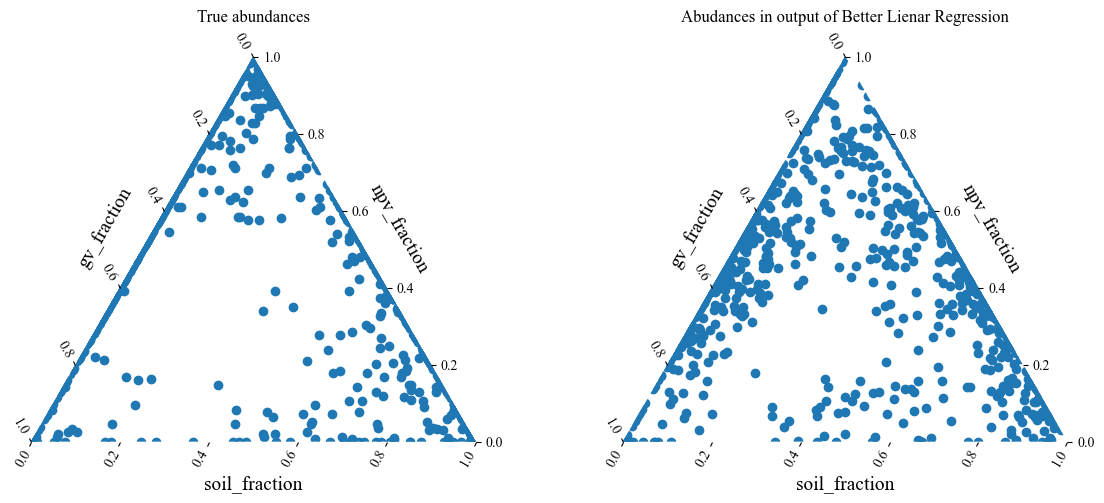

In [28]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Better Lienar Regression")

In [11]:
helper_functions.plot_preds(
    ab_true=y_test.to_numpy(), 
    ab_pred=ab_clipnormed_predictions, 
    save_path="better_linear_regression.svg",
    model_name="Better Linear Regression"
)
slope, intercept, r, p, se = scipy.stats.linregress(y_test.to_numpy(), ab_clipnormed_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

# Atmospheric Data

### Ridge Regression
The following demonstractions are best made using Ridge Regression. Note that Ridge Regression with `alpha=0.0` is equivalent to traditional Linear Regression.

In [19]:
df = helper_functions.open_file(ATMO_DATA)
at_fractions, at900to1690 = helper_functions.take_subset(df, 900, 1690)
assert all(at_fractions['gv_fraction'] == 0)
at_fractions = at_fractions[["npv_fraction", "soil_fraction"]]

In [44]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(at900to1690, at_fractions, test_size=0.2, random_state=30)
ridge_regression = sklearn.linear_model.Ridge(alpha=0.01)
ridge_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

print(ridge_regression.score(X_train, y_train))
print(ridge_regression.score(X_test, y_test))

0.23029859016356108
-0.1450869501041715


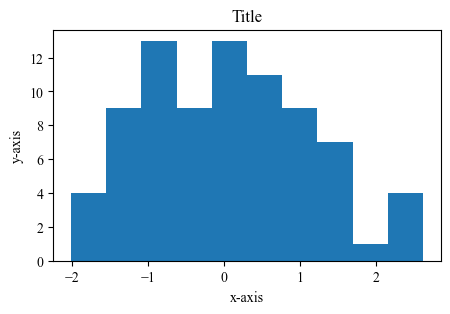

In [45]:
helper_functions.simple_histogram(ridge_regression.coef_[0])

In [23]:
ab_true_np_array = y_test.to_numpy()
ab_predictions = ridge_regression.predict(X_test)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"soil r^2 = {r[1]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

npv r^2 = 0.029427388076061906
soil r^2 = 0.029427388075946595
mean r^2 = 0.02942738807600425


In [ ]:
dataset = nr900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1))
normalized_dataset = dataset.copy()
for i in range(dataset.shape[0]):
    normalized_dataset.loc[i] /= norms[i]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(post_norms.min(), post_norms.max())
nr900to1690 = normalized_dataset